# Part I: Preprocessing

## Basic settings

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.options.display.max_rows = 50
pd.options.display.max_columns = None

In [3]:
DATA_DIR = "../data/raw"

## Load and clean data

In [4]:
df_inventory = pd.read_csv(os.path.join(DATA_DIR, "inventory.csv"))

In [5]:
df_inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109650 entries, 0 to 109649
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   sku_id           109650 non-null  object 
 1   date             109650 non-null  object 
 2   demand           109650 non-null  int64  
 3   sales_quantity   109650 non-null  int64  
 4   inventory_level  109650 non-null  int64  
 5   order_received   109650 non-null  int64  
 6   category         109650 non-null  object 
 7   lead_time        109650 non-null  int64  
 8   safety_stock     109650 non-null  int64  
 9   reorder_point    109650 non-null  int64  
 10  order_quantity   109650 non-null  int64  
 11  unit_cost        109650 non-null  float64
 12  unit_price       109650 non-null  float64
dtypes: float64(2), int64(8), object(3)
memory usage: 10.9+ MB


In [6]:
df_inventory.head()

,sku_id,date,demand,sales_quantity,inventory_level,order_received,category,lead_time,safety_stock,reorder_point,order_quantity,unit_cost,unit_price
0,SKU0001,2024-01-01,10,10,290,0,Laptop,5,10,135,615,695.87,1156.65
1,SKU0001,2024-01-02,1,1,289,0,Laptop,5,10,135,615,695.87,1156.65
2,SKU0001,2024-01-03,4,4,285,0,Laptop,5,10,135,615,695.87,1156.65
3,SKU0001,2024-01-04,2,2,283,0,Laptop,5,10,135,615,695.87,1156.65
4,SKU0001,2024-01-05,1,1,282,0,Laptop,5,10,135,615,695.87,1156.65


### Handle missing values

In [7]:
df_inventory.isna().sum()

sku_id             0
date               0
demand             0
sales_quantity     0
inventory_level    0
order_received     0
category           0
lead_time          0
safety_stock       0
reorder_point      0
order_quantity     0
unit_cost          0
unit_price         0
dtype: int64

### Handle duplicate values

In [8]:
df_inventory.duplicated(subset = ['sku_id', 'date']).sum()

np.int64(0)

### Syntax errors

In [9]:
cate_cols = ['sku_id', 'date', 'category']
for col in cate_cols:
    print(f"{col} unique values: {df_inventory[col].unique()}")
    print("===================================")

sku_id unique values: ['SKU0001' 'SKU0002' 'SKU0003' 'SKU0004' 'SKU0005' 'SKU0006' 'SKU0007'
 'SKU0008' 'SKU0009' 'SKU0010' 'SKU0011' 'SKU0012' 'SKU0013' 'SKU0014'
 'SKU0015' 'SKU0016' 'SKU0017' 'SKU0018' 'SKU0019' 'SKU0020' 'SKU0021'
 'SKU0022' 'SKU0023' 'SKU0024' 'SKU0025' 'SKU0026' 'SKU0027' 'SKU0028'
 'SKU0029' 'SKU0030' 'SKU0031' 'SKU0032' 'SKU0033' 'SKU0034' 'SKU0035'
 'SKU0036' 'SKU0037' 'SKU0038' 'SKU0039' 'SKU0040' 'SKU0041' 'SKU0042'
 'SKU0043' 'SKU0044' 'SKU0045' 'SKU0046' 'SKU0047' 'SKU0048' 'SKU0049'
 'SKU0050' 'SKU0051' 'SKU0052' 'SKU0053' 'SKU0054' 'SKU0055' 'SKU0056'
 'SKU0057' 'SKU0058' 'SKU0059' 'SKU0060' 'SKU0061' 'SKU0062' 'SKU0063'
 'SKU0064' 'SKU0065' 'SKU0066' 'SKU0067' 'SKU0068' 'SKU0069' 'SKU0070'
 'SKU0071' 'SKU0072' 'SKU0073' 'SKU0074' 'SKU0075' 'SKU0076' 'SKU0077'
 'SKU0078' 'SKU0079' 'SKU0080' 'SKU0081' 'SKU0082' 'SKU0083' 'SKU0084'
 'SKU0085' 'SKU0086' 'SKU0087' 'SKU0088' 'SKU0089' 'SKU0090' 'SKU0091'
 'SKU0092' 'SKU0093' 'SKU0094' 'SKU0095' 'SKU0096' 'SKU

### Type convention

In [10]:
df_inventory['date'] = pd.to_datetime(df_inventory['date'])

### Check outliers values

In [11]:
nums_cols = df_inventory.select_dtypes(include = ['number']).columns
df_inventory[nums_cols].describe()

,demand,sales_quantity,inventory_level,order_received,lead_time,safety_stock,reorder_point,order_quantity,unit_cost,unit_price
count,109650.000000,109650.000000,109650.000000,109650.000000,109650.000000,109650.000000,109650.000000,109650.000000,109650.000000,109650.000000
mean,15.028299,14.385846,337.580164,14.421332,6.646667,44.260000,145.546667,563.760000,627.705267,1245.871533
std,9.711968,9.650186,196.420558,89.473497,3.435394,19.764175,37.578106,139.073789,346.556135,730.776230
min,0.000000,0.000000,0.000000,0.000000,3.000000,10.000000,65.000000,300.000000,20.200000,29.420000
25%,8.000000,7.000000,186.000000,0.000000,3.000000,28.000000,117.000000,461.000000,313.300000,643.330000
50%,13.000000,12.000000,318.000000,0.000000,5.000000,42.000000,144.000000,558.500000,618.530000,1190.660000
75%,20.000000,20.000000,475.000000,0.000000,10.000000,61.000000,175.000000,684.000000,930.610000,1803.520000
max,75.000000,75.000000,937.000000,800.000000,14.000000,79.000000,227.000000,800.000000,1195.500000,2838.460000


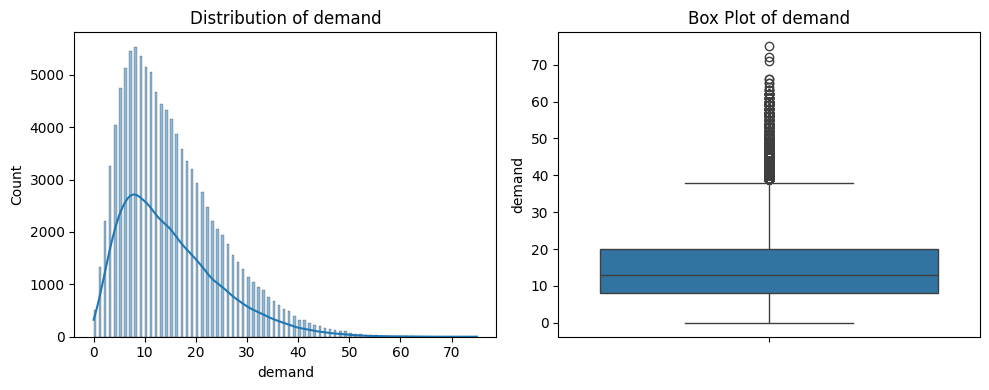

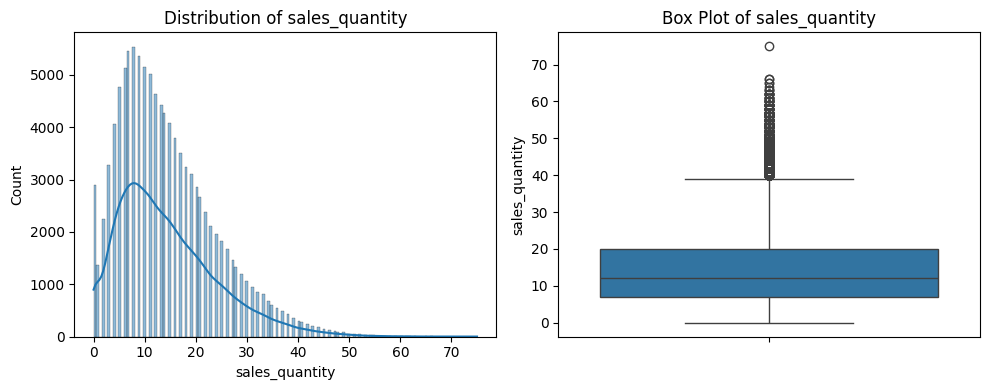

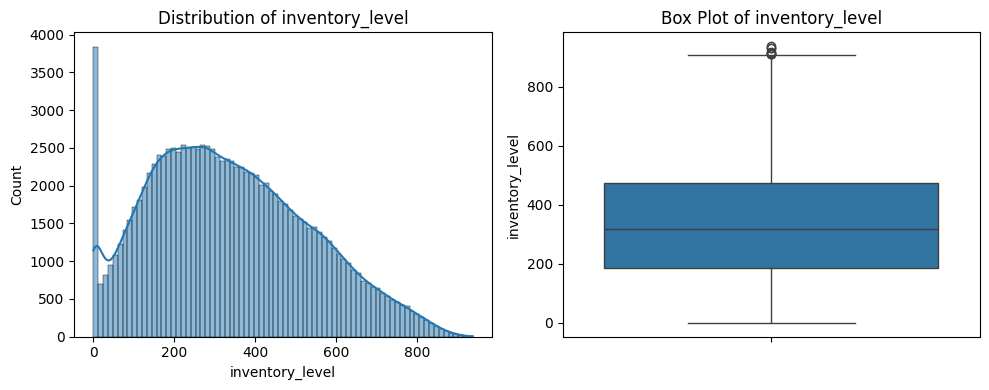

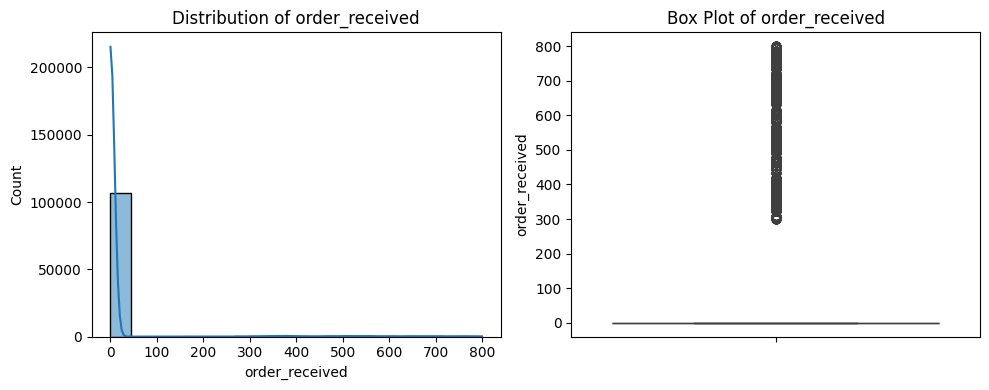

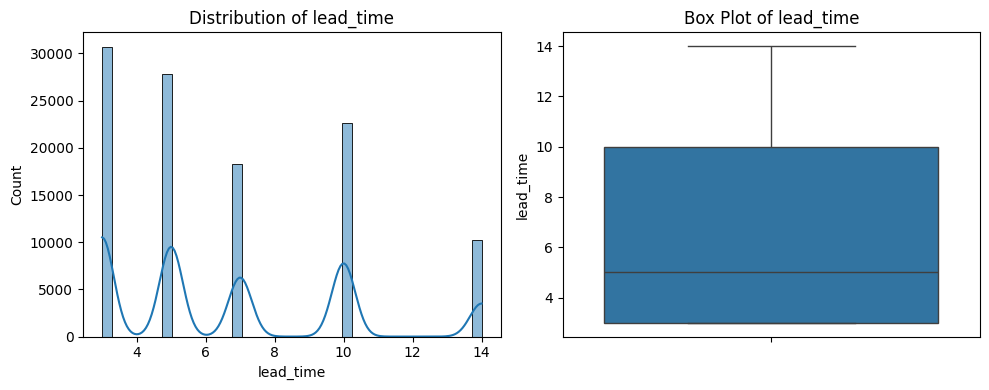

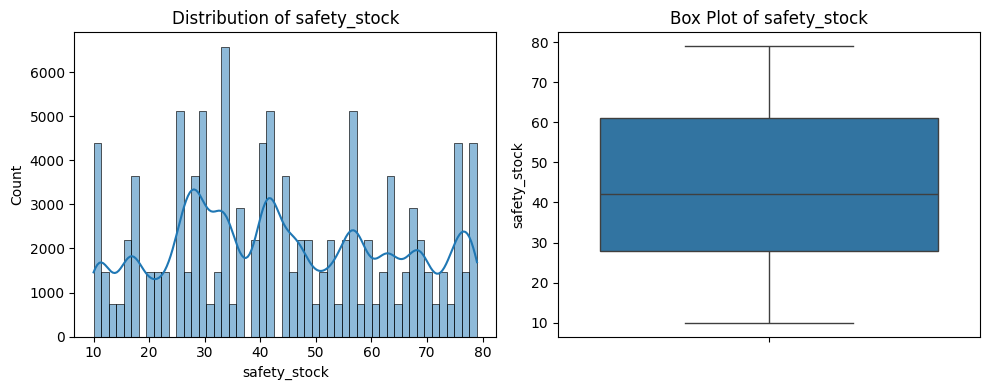

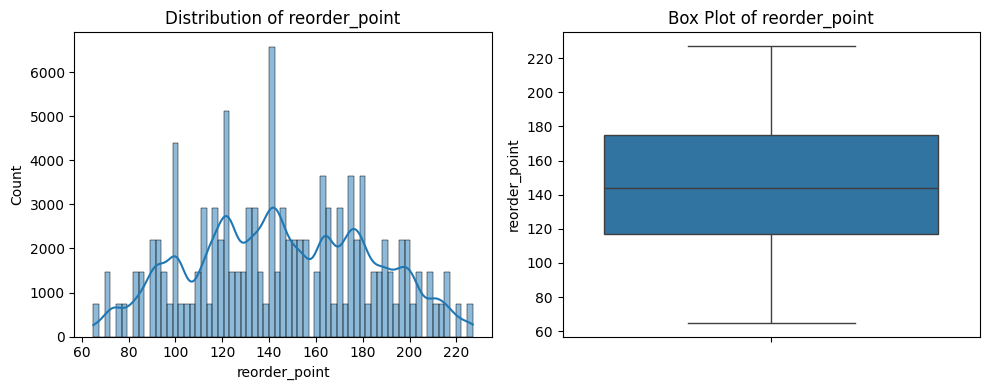

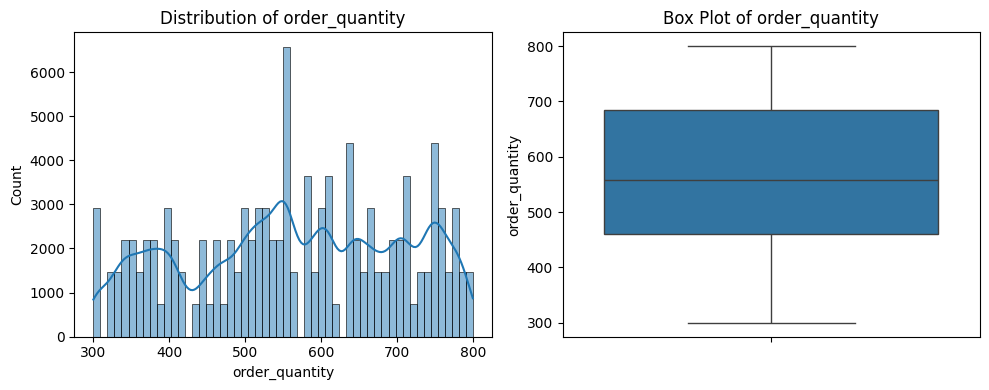

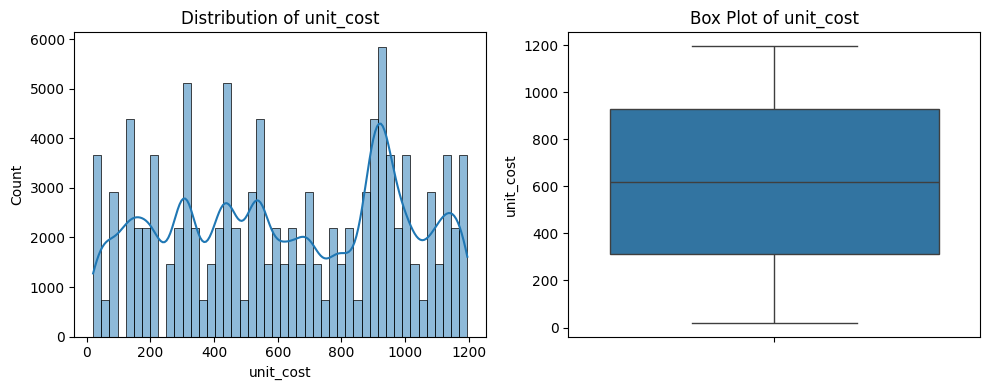

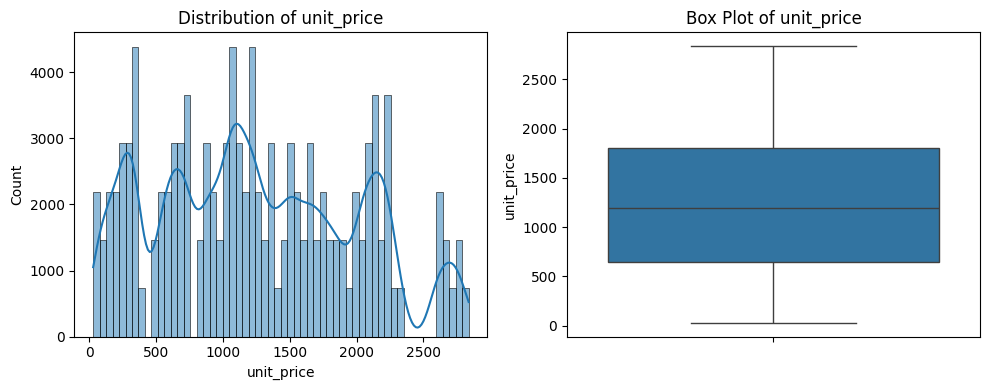

In [12]:
n_rows, n_cols = 10, 2

for col in nums_cols:
    fig, ax = plt.subplots(1, 2, figsize = (10, 4))

    sns.histplot(df_inventory[col], ax = ax[0], kde = True)
    ax[0].set_title(f"Distribution of {col}")

    sns.boxplot(y = df_inventory[col], ax = ax[1])
    ax[1].set_title(f"Box Plot of {col}")

    plt.tight_layout()
    plt.show()

## Save preprocessed data

In [13]:
df_inventory.to_csv("../data/processed/inventory_processed.csv", index = False)